# IA-GTPF tree ensemble

Causal temporal, graph and quality features feed tree models. Training estimates model parameters, validation selects convex blending weights, and a separate calibration period adjusts prediction intervals.

Deterministic components may be reused across seeds only for identical training arrays, sample weights, hyperparameters and software versions. Runtime measurements distinguish fitted and reused components.

In [1]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

_nb_reuse('src-03-001', globals())


## Shared matrix and runtime utilities

In [2]:
_nb_reuse('src-03-003', globals(), names=['select_training_rows'])

_nb_reuse('src-03-003', globals(), names=['fit_matrix'])

_nb_reuse('src-03-003', globals(), names=['transform_matrix'])

runtime_rows=[]
_nb_reuse('src-03-003', globals(), names=['timed_fit'])

_nb_reuse('src-03-003', globals(), names=['prediction_frame'])

_nb_reuse('src-03-003', globals(), names=['point_metrics'])

# Deterministic branches may be reused only for identical training arrays and parameters.
# Main-model timing is fresh; rolling origins reuse deterministic fits across seeds.
REUSE_DETERMINISTIC_COMPONENTS=False

def fit_deterministic(model,x,y,**kwargs):
    if not REUSE_DETERMINISTIC_COMPONENTS:return timed_fit(model,x,y,**kwargs)
    import sklearn
    digest=hashlib.sha256(json.dumps({'params':model.get_params(),'sklearn':sklearn.__version__},sort_keys=True,default=str).encode())
    for value in [x,y,kwargs.get('sample_weight')]:
        if value is None:digest.update(b'None')
        else:
            arr=np.ascontiguousarray(value);digest.update(str((arr.shape,str(arr.dtype))).encode());digest.update(arr.tobytes())
    cache_dir=MODEL_DIR/'deterministic_components';cache_dir.mkdir(exist_ok=True)
    path=cache_dir/(digest.hexdigest()+'.joblib')
    if path.exists():
        began=time.perf_counter();fitted=load_model(path)
        runtime_rows.append({'estimator':type(model).__name__,'fit_seconds':0.,'load_seconds':time.perf_counter()-began,'n_train':len(y),'n_features':x.shape[1],'mode':'cached_deterministic_component','cache_key':digest.hexdigest(),'threads':protocol['threads']})
        return fitted
    fitted=timed_fit(model,x,y,**kwargs)
    joblib.dump(fitted,path)
    runtime_rows[-1]['cache_key']=digest.hexdigest()
    return fitted


_nb_reuse('src-03-003', globals(), names=['load_model'])


In [3]:
_nb_reuse('src-03-005', globals())


## One explicit IA_GTPF_CONFIG

In [4]:
IA_GTPF_CONFIG={
 'revision':'raw_causal_tree_ensemble_v1',
 'preprocessing':protocol,
 'training_row_cap':36000,
 'hgb_candidates':[{'max_iter':180,'learning_rate':.05,'max_leaf_nodes':31,'l2_regularization':.05},{'max_iter':240,'learning_rate':.035,'max_leaf_nodes':45,'l2_regularization':.10}],
 'extratrees':{'n_estimators':70,'max_depth':18,'min_samples_leaf':4},
 'residual':{'max_iter':90,'learning_rate':.04,'max_leaf_nodes':23,'l2_regularization':.08},
 'quantile':{'max_iter':190,'learning_rate':.045,'max_leaf_nodes':45,'l2_regularization':.08},
 'anchor':{'max_iter':180,'learning_rate':.05,'max_leaf_nodes':31,'l2_regularization':.05},
 'robust_extratrees':{'n_estimators':80,'max_depth':20,'min_samples_leaf':4},
 'quantiles':[.05,.5,.95],
 'blend_grid_step':.1,
 'residual_weak_weight_bonus':.75,
 'residual_fit':'in_sample_training_residuals; retained from the actual tree implementation, not out-of-fold residuals',
 'quality_weight':'clip((clip(1-.45*channel_missingness-.35*net_missing-.20*anomaly,.05,1))/(1+.1*gap_length),.03,1)',
 'empirical_bounds':{'quantiles':[.001,.999],'std_multiplier':1.5,'physical_capacity_claim':False},
 'conformal_alpha':.10,
 'hgb_random_state':0,
 'hgb_early_stopping':False,
 'validation_regime_bias':False,
 'graph':{'neighbors':protocol['graph_neighbors'],'self_edges':False,'positive_train_correlation_only':True,'min_pairwise_observations':500},
 'regime_thresholds':{'weak_min_abs_ramp_kw':.02,'weak_train_abs_ramp_quantile':.35,'rapid_train_abs_ramp_quantile':.85,'pv_train_quantiles':[.3,.7]},
 'anomaly_screen':{'train_quantile':.99,'multiplier':20.}
}
QUALITY_FEATURES={'missingness_ratio','input_missing_flag','gap_length','data_quality_score','imputed_value_confidence_weight','raw_anomaly_flag','high_interpolation_regime'}
WEAK_FEATURES={'weak_signal_regime','rapid_ramp_flag','ramp_scale','net_load_ramp_kw'}

def variant_columns(columns,variant):
    keep=list(columns)
    if variant=='without_graph':keep=[c for c in keep if not c.startswith('graph_')]
    if variant=='without_interpolation':keep=[c for c in keep if c not in QUALITY_FEATURES]
    if variant=='without_weak_signal':keep=[c for c in keep if c not in WEAK_FEATURES]
    return keep

def hgb_model(params,**kwargs):
    return HistGradientBoostingRegressor(**params,random_state=IA_GTPF_CONFIG['hgb_random_state'],early_stopping=False,**kwargs)


## Fit the full ensemble and its precisely scoped variants

In [5]:
def fit_ia_gtpf(train,validation,h,seed,columns,variant='full'):
    """Fit train-only trees; select all blend coefficients on validation; never access calibration/test."""
    assert train.split.eq('train').all() and validation.split.eq('validation').all()
    began=time.perf_counter();runtime_start=len(runtime_rows)
    target=f'target_h{h}_net_load_kw';fit=select_training_rows(train,h,IA_GTPF_CONFIG['training_row_cap'])
    val=validation.loc[validation[f'target_measured_h{h}']]
    selected=variant_columns(columns,variant);matrix=fit_matrix(train,selected)
    x=transform_matrix(fit,matrix);xv=transform_matrix(val,matrix)
    y=fit[target].to_numpy();yv=val[target].to_numpy()
    weights=fit.imputed_value_confidence_weight.to_numpy() if variant!='without_interpolation' else None
    candidates=[];fitted=[]
    for params in IA_GTPF_CONFIG['hgb_candidates']:
        model=fit_deterministic(hgb_model(params),x,y,sample_weight=weights)
        candidates.append({'params':params,'validation_MAE':float(mean_absolute_error(yv,model.predict(xv)))});fitted.append(model)
    best=int(np.argmin([r['validation_MAE'] for r in candidates]));hgb=fitted[best]
    et=timed_fit(ExtraTreesRegressor(**IA_GTPF_CONFIG['extratrees'],random_state=seed,n_jobs=protocol['threads']),x,y,sample_weight=weights)
    ph,pe=hgb.predict(xv),et.predict(xv)
    blend_grid=np.linspace(0.,1.,11)
    blend=float(min(blend_grid,key=lambda w:mean_absolute_error(yv,w*ph+(1-w)*pe)))
    residual=None
    if variant!='without_residual':
        residual_target=y-(blend*hgb.predict(x)+(1-blend)*et.predict(x))
        rw=np.ones(len(fit)) if variant=='without_weak_signal' else 1+IA_GTPF_CONFIG['residual_weak_weight_bonus']*fit.weak_signal_regime.to_numpy()
        if weights is not None:rw*=weights
        residual=fit_deterministic(hgb_model(IA_GTPF_CONFIG['residual']),x,residual_target,sample_weight=rw)
    quantiles={}
    for q in IA_GTPF_CONFIG['quantiles']:
        quantiles[q]=fit_deterministic(hgb_model(IA_GTPF_CONFIG['quantile'],loss='quantile',quantile=q),x,y,sample_weight=weights)
    anchor=fit_deterministic(hgb_model(IA_GTPF_CONFIG['anchor'],loss='quantile',quantile=.5),x,y)
    robust_columns=[c for c in selected if c not in QUALITY_FEATURES]
    robust_matrix=fit_matrix(train,robust_columns)
    robust=timed_fit(ExtraTreesRegressor(**IA_GTPF_CONFIG['robust_extratrees'],random_state=seed,n_jobs=protocol['threads']),transform_matrix(fit,robust_matrix),y)
    rv=np.zeros(len(val)) if residual is None else residual.predict(xv)
    branch_predictions=np.column_stack([blend*ph+(1-blend)*pe+rv,quantiles[.5].predict(xv)+rv,anchor.predict(xv),robust.predict(transform_matrix(val,robust_matrix))])
    best_score=np.inf;point_weights=None
    for a in range(11):
        for b in range(11-a):
            for c in range(11-a-b):
                if variant=='without_probabilistic_branch_in_point_aggregation' and (b>0 or c>0):continue
                w=np.array([a,b,c,10-a-b-c])/10.
                score=float(np.mean(np.abs(yv-branch_predictions@w)))
                if score<best_score:best_score=score;point_weights=w
    bounds=train.loc[train[f'target_measured_h{h}']].groupby('site')[target].quantile([.001,.999]).unstack()
    spread=train.loc[train[f'target_measured_h{h}']].groupby('site')[target].std()
    bounds.columns=['lower','upper'];bounds['lower']-=1.5*spread;bounds['upper']+=1.5*spread
    bundle={'h':h,'seed':seed,'variant':variant,'matrix':matrix,'hgb':hgb,'extratrees':et,'hgb_weight':blend,'residual':residual,'quantiles':quantiles,'anchor':anchor,'robust_extratrees':robust,'robust_matrix':robust_matrix,'point_weights':point_weights,'bounds':bounds,'qhat':None,'validation_MAE':best_score,'hgb_candidates':candidates,'config':copy.deepcopy(IA_GTPF_CONFIG)}
    bundle['fit_seconds']=time.perf_counter()-began
    bundle['deterministic_component_reuse_enabled']=REUSE_DETERMINISTIC_COMPONENTS
    bundle['training_row_hash']=hashlib.sha256(pd.util.hash_pandas_object(fit[['site','timestamp']],index=False).values.tobytes()).hexdigest()
    for row in runtime_rows[runtime_start:]:row.update({'model':'IA-GTPF','horizon_minutes':15*h,'seed':seed,'variant':variant})
    return bundle


## Prediction, dedicated calibration and configuration export
Ablating conformal changes only interval endpoints. Ablating the probabilistic contribution to point aggregation is a different fitted variant.

In [6]:
def predict_ia_gtpf(bundle,frame,conformal=True,clip=True):
    """Point aggregation is invariant to conformal; empirical clipping is separately switchable."""
    x=transform_matrix(frame,bundle['matrix'])
    residual=np.zeros(len(frame)) if bundle['residual'] is None else bundle['residual'].predict(x)
    det=bundle['hgb_weight']*bundle['hgb'].predict(x)+(1-bundle['hgb_weight'])*bundle['extratrees'].predict(x)+residual
    q=np.column_stack([bundle['quantiles'][a].predict(x)+residual for a in [.05,.5,.95]])
    branches=np.column_stack([det,q[:,1],bundle['anchor'].predict(x),bundle['robust_extratrees'].predict(transform_matrix(frame,bundle['robust_matrix']))])
    point=branches@bundle['point_weights'];q=np.sort(q,axis=1)
    raw_point=point.copy();raw_q=q.copy()
    if conformal:
        if bundle['qhat'] is None:raise RuntimeError('Dedicated calibration must be fitted before conformal prediction')
        q[:,0]-=bundle['qhat'];q[:,2]+=bundle['qhat']
    preclip_point=point.copy();preclip_q=q.copy()
    if clip:
        lower=frame.site.map(bundle['bounds']['lower']).to_numpy();upper=frame.site.map(bundle['bounds']['upper']).to_numpy()
        assert np.isfinite(lower).all() and np.isfinite(upper).all()
        point=np.clip(point,lower,upper);q=np.clip(q,lower[:,None],upper[:,None])
    return {'pred':point,'lower':q[:,0],'median':q[:,1],'upper':q[:,2],'raw_point':raw_point,'raw_lower':raw_q[:,0],'raw_median':raw_q[:,1],'raw_upper':raw_q[:,2],'preclip_pred':preclip_point,'preclip_lower':preclip_q[:,0],'preclip_median':preclip_q[:,1],'preclip_upper':preclip_q[:,2],'point_clip':point!=preclip_point,'interval_clip':np.any(q!=preclip_q,axis=1)}

def calibrate_ia_gtpf(bundle,calibration):
    h=bundle['h'];cal=calibration.loc[calibration[f'target_measured_h{h}']]
    assert cal.split.eq('calibration').all()
    began=time.perf_counter();raw=predict_ia_gtpf(bundle,cal,conformal=False,clip=False)
    bundle['qhat']=finite_sample_correction(conformity_score(cal[f'target_h{h}_net_load_kw'],raw['lower'],raw['upper']),IA_GTPF_CONFIG['conformal_alpha'])
    bundle['calibration_seconds']=time.perf_counter()-began
    # A pure conformal ablation must leave every point forecast unchanged.
    before=predict_ia_gtpf(bundle,cal.iloc[:128],conformal=False)['pred']
    after=predict_ia_gtpf(bundle,cal.iloc[:128],conformal=True)['pred']
    bundle['conformal_point_check_max_abs_kw']=float(np.max(np.abs(before-after)))
    np.testing.assert_allclose(before,after,rtol=0,atol=1e-12)
    return bundle

def export_ia_configuration(bundle,path):
    values={**bundle['config'],'horizon_minutes':bundle['h']*15,'seed':bundle['seed'],'variant':bundle['variant'],'hgb_weight':bundle['hgb_weight'],'point_weights':dict(zip(['deterministic','quantile_median','anchor','robust'],bundle['point_weights'].tolist())),'validation_MAE':bundle['validation_MAE'],'training_row_hash':bundle['training_row_hash'],'selected_features':bundle['matrix']['columns'],'empirical_bounds':bundle['bounds'].to_dict(),'fitted_models':{}}
    for key in ['hgb','extratrees','residual','anchor','robust_extratrees']:
        if bundle[key] is not None:values['fitted_models'][key]=bundle[key].get_params()
    for q,model in bundle['quantiles'].items():values['fitted_models'][f'quantile_{q}']=model.get_params()
    path.write_text(json.dumps(values,indent=2,default=str))
    return values


## Fit full models for both horizons and five seeds
No final test metrics are computed here. The serialized model and complete effective hyperparameters are saved after every fit.

In [8]:
selection_rows=[];configs=[];progress=display(Markdown('IA-GTPF validation selection; final test locked'),display_id=True)
for h in protocol['horizons']:
    train=modeling.loc[modeling.split.eq('train')];validation=modeling.loc[modeling.split.eq('validation')]
    for seed in protocol['seeds']:
        progress.update(Markdown(f'Fitting complete **IA-GTPF**, horizon **{15*h} min**, seed **{seed}**'))
        bundle=fit_ia_gtpf(train,validation,h,seed,feature_cols)
        stem=f'ia_gtpf_h{h}_seed{seed}'
        joblib.dump(bundle,MODEL_DIR/(stem+'.joblib'))
        configs.append(export_ia_configuration(bundle,STATE_DIR/(stem+'_config.json')))
        selection_rows.append({'horizon_minutes':15*h,'seed':seed,'validation_MAE':bundle['validation_MAE'],'fit_seconds':bundle['fit_seconds'],'hgb_weight':bundle['hgb_weight'],**dict(zip(['point_w_deterministic','point_w_median','point_w_anchor','point_w_robust'],bundle['point_weights']))})
        pd.DataFrame(selection_rows).to_csv(TABLE_DIR/'ia_gtpf_validation_selection.csv',index=False)
        pd.DataFrame(runtime_rows).to_csv(TABLE_DIR/'ia_gtpf_fresh_fit_runtime.csv',index=False)
        progress.update(Markdown(f'Complete **{15*h} min**, seed **{seed}**; validation MAE **{bundle["validation_MAE"]:.4f} kW**'))
        del bundle
parameter_rows=[]
for config in configs:
    for branch,params in config['fitted_models'].items():
        for key,value in params.items():parameter_rows.append({'horizon_minutes':config['horizon_minutes'],'seed':config['seed'],'branch':branch,'parameter':key,'value':str(value)})
pd.DataFrame(parameter_rows).to_csv(TABLE_DIR/'ia_gtpf_final_hyperparameters.csv',index=False)
(STATE_DIR/'ia_gtpf_selection_complete.json').write_text(json.dumps({'status':'COMPLETE','models':len(configs),'test_accessed':False},indent=2))
display(pd.DataFrame(selection_rows))


,horizon_minutes,seed,validation_MAE,fit_seconds,hgb_weight,point_w_deterministic,point_w_median,point_w_anchor,point_w_robust
0,15,11,1.179768,63.196082,0.4,0.1,0.4,0.1,0.4
1,15,23,1.179485,32.461549,0.4,0.1,0.4,0.1,0.4
2,15,37,1.180538,27.652491,0.4,0.3,0.4,0.0,0.3
3,15,53,1.178276,30.634860,0.4,0.2,0.4,0.1,0.3
4,15,71,1.178907,30.122761,0.4,0.1,0.4,0.1,0.4
5,60,11,1.571000,25.090430,0.5,0.3,0.4,0.1,0.2
6,60,23,1.571848,27.084026,0.5,0.3,0.4,0.1,0.2
7,60,37,1.574959,25.984493,0.5,0.3,0.5,0.1,0.1
8,60,53,1.573876,29.856190,0.5,0.3,0.4,0.1,0.2
9,60,71,1.573514,27.383905,0.5,0.4,0.4,0.1,0.1


## Repeated ablations and delayed-neighbor sensitivity

Every fitted ablation uses the same five origins, five seeds and paired targets as the full model. The pure conformal ablation reuses identical point predictions and changes only intervals. A separate ablation removes quantile/median-anchor contributions from point aggregation. No main final-test score is used here.

The quality ablation disables quality-related predictors and sample weights, while retaining essential causal preprocessing and target validity checks. The weak-signal ablation removes its ramp-feature block and residual reweighting.

In [1]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

from pathlib import Path
import json, hashlib, time, copy, os, threading
import numpy as np
import pandas as pd
import joblib, psutil
from IPython.display import display, Markdown
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from quantile_forest import RandomForestQuantileRegressor
from threadpoolctl import threadpool_limits
PROJECT_DIR=_repo_root()
TABLE_DIR,STATE_DIR,MODEL_DIR,PREDICT_DIR=[PROJECT_DIR/x for x in ['.cache/experiment/tables','.cache/experiment/state','.cache/experiment/models','.cache/experiment/predictions']]
for directory in [TABLE_DIR,STATE_DIR,MODEL_DIR,PREDICT_DIR]:directory.mkdir(exist_ok=True)
protocol=json.loads((STATE_DIR/'experiment_config.json').read_text())
assert json.loads((STATE_DIR/'temporal_consistency.json').read_text())['status']=='PASS'
modeling=pd.read_parquet(TABLE_DIR/'modeling_dataset.parquet')
feature_cols=json.loads((STATE_DIR/'main_preprocessing_state.json').read_text())['feature_columns']
pd.set_option('display.max_rows',100);pd.set_option('display.max_columns',20);pd.set_option('display.max_colwidth',None)
threadpool_limits(protocol['threads'])

base_panel=pd.read_parquet(TABLE_DIR/'causal_base_panel.parquet')
origins=pd.read_csv(TABLE_DIR/'rolling_origin_splits.csv',parse_dates=['start','end'])

assert json.loads((STATE_DIR/'rolling_origin_complete.json').read_text())['status']=='COMPLETE'


## Canonical fold-local preprocessing

In [2]:
_nb_reuse('src-02-012', globals())


## Shared model matrices, metrics and runtime

In [3]:
_nb_reuse('src-03-003', globals(), names=['select_training_rows'])

_nb_reuse('src-03-003', globals(), names=['fit_matrix'])

_nb_reuse('src-03-003', globals(), names=['transform_matrix'])

runtime_rows=[]
_nb_reuse('src-03-003', globals(), names=['timed_fit'])

_nb_reuse('src-03-003', globals(), names=['prediction_frame'])

_nb_reuse('src-03-003', globals(), names=['point_metrics'])

# Deterministic branches may be reused only for identical training arrays and parameters.
# Main-model timing is fresh; rolling origins reuse deterministic fits across seeds.
REUSE_DETERMINISTIC_COMPONENTS=False

_nb_reuse('src-04-003', globals(), names=['fit_deterministic'])

REUSE_DETERMINISTIC_COMPONENTS=True


_nb_reuse('src-03-003', globals(), names=['load_model'])


def quantile_predict(model,x,quantiles):
    """Exact row-parallel QRF prediction; four workers, one tree worker each."""
    if len(x)<256:return model.predict(x,quantiles=quantiles,weighted_leaves=True)
    from concurrent.futures import ThreadPoolExecutor
    workers=min(protocol['threads'],len(x));original_jobs=model.n_jobs;model.n_jobs=1
    try:
        chunks=np.array_split(x,workers)
        with ThreadPoolExecutor(max_workers=workers) as pool:
            pieces=list(pool.map(lambda part:model.predict(part,quantiles=quantiles,weighted_leaves=True),chunks))
        return np.concatenate(pieces,axis=0)
    finally:model.n_jobs=original_jobs


## Conformal order statistic

In [4]:
_nb_reuse('src-03-005', globals())


## Strong baseline definitions

In [5]:
_nb_reuse('src-03-007', globals(), names=['memory_efficient_leaf_mapping'])

_nb_reuse('src-03-007', globals(), names=['fit_memory_safe_quantile_forest'])


BASELINE_CONFIG={
 'Ridge':[{'alpha':.5},{'alpha':5.},{'alpha':25.}],
 'ExtraTrees':[{'n_estimators':90,'max_depth':14,'min_samples_leaf':4},{'n_estimators':110,'max_depth':18,'min_samples_leaf':6}],
 'RandomForest':[{'n_estimators':80,'max_depth':12,'min_samples_leaf':4},{'n_estimators':100,'max_depth':16,'min_samples_leaf':6}],
 'HGB':[{'max_iter':160,'learning_rate':.06,'max_leaf_nodes':31,'l2_regularization':.05},{'max_iter':220,'learning_rate':.04,'max_leaf_nodes':45,'l2_regularization':.10}],
 'QuantileForest':[{'n_estimators':90,'max_depth':14,'min_samples_leaf':4},{'n_estimators':110,'max_depth':18,'min_samples_leaf':6}],
 'QuantileHGB':[{'max_iter':180,'learning_rate':.05,'max_leaf_nodes':31,'l2_regularization':.05},{'max_iter':220,'learning_rate':.04,'max_leaf_nodes':45,'l2_regularization':.10}]
}

def fit_baseline(train,validation,h,name,seed,columns):
    assert train.split.eq('train').all() and validation.split.eq('validation').all()
    runtime_start=len(runtime_rows)
    target=f'target_h{h}_net_load_kw';fit=select_training_rows(train,h);val=validation.loc[validation[f'target_measured_h{h}']]
    state=fit_matrix(train,columns);x=transform_matrix(fit,state);xv=transform_matrix(val,state)
    y=fit[target].to_numpy();yv=val[target].to_numpy();candidates=[];models=[]
    for params in BASELINE_CONFIG[name]:
        if name=='Ridge':model=make_pipeline(StandardScaler(),Ridge(**params))
        elif name=='ExtraTrees':model=ExtraTreesRegressor(**params,random_state=seed,n_jobs=protocol['threads'])
        elif name=='RandomForest':model=RandomForestRegressor(**params,random_state=seed,n_jobs=protocol['threads'])
        elif name=='QuantileForest':model=RandomForestQuantileRegressor(**params,max_samples_leaf=None,random_state=seed,n_jobs=protocol['threads'])
        else:model=HistGradientBoostingRegressor(**params,random_state=0,early_stopping=False,**({'loss':'quantile','quantile':.5} if name=='QuantileHGB' else {}))
        fit_memory_safe_quantile_forest(model,x,y) if name=='QuantileForest' else timed_fit(model,x,y)
        pred=quantile_predict(model,xv,.5) if name=='QuantileForest' else model.predict(xv)
        candidates.append({'params':params,'validation_MAE':float(mean_absolute_error(yv,pred))});models.append(model)
    best=int(np.argmin([r['validation_MAE'] for r in candidates]))
    bundle={'name':name,'seed':seed,'h':h,'matrix':state,'model':models[best],'selected':candidates[best],'candidates':candidates,'qhat':None}
    if name=='QuantileHGB':
        bundle['quantiles']={.5:models[best]}
        for q in [.05,.95]:bundle['quantiles'][q]=timed_fit(HistGradientBoostingRegressor(**candidates[best]['params'],loss='quantile',quantile=q,random_state=0,early_stopping=False),x,y)
    bundle['training_row_hash']=hashlib.sha256(pd.util.hash_pandas_object(fit[['site','timestamp']],index=False).values.tobytes()).hexdigest()
    for row in runtime_rows[runtime_start:]:row.update({'model':name,'horizon_minutes':15*h,'seed':seed})
    bundle['effective_parameters']=bundle['model'].get_params()
    if name=='QuantileForest':
        check=quantile_predict(bundle['model'],xv,.5)
        assert abs(mean_absolute_error(yv,check)-bundle['selected']['validation_MAE'])<1e-10
    bundle['prediction_options']={'quantiles':[.05,.5,.95],'weighted_leaves':True,'weighted_quantile':True,'aggregate_leaves_first':True} if name=='QuantileForest' else {}
    return bundle

def predict_baseline(bundle,frame,calibrated=True):
    x=transform_matrix(frame,bundle['matrix']);model=bundle['model'];name=bundle['name']
    if name=='QuantileForest':q=np.sort(quantile_predict(model,x,[.05,.5,.95]),axis=1);point=q[:,1]
    elif name=='QuantileHGB':q=np.sort(np.column_stack([bundle['quantiles'][z].predict(x) for z in [.05,.5,.95]]),axis=1);point=q[:,1]
    else:point=model.predict(x);q=None
    if calibrated and bundle.get('qhat') is not None:
        if q is None:q=np.column_stack([point,point,point])
        q[:,0]-=bundle['qhat'];q[:,2]+=bundle['qhat']
    return point,q

_nb_reuse('src-03-007', globals(), names=['calibrate_baseline'])


## IA-GTPF configuration

In [6]:
_nb_reuse('src-04-006', globals())


## Complete IA-GTPF training

In [7]:
def fit_ia_gtpf(train,validation,h,seed,columns,variant='full'):
    """Fit train-only trees; select all blend coefficients on validation; never access calibration/test."""
    assert train.split.eq('train').all() and validation.split.eq('validation').all()
    began=time.perf_counter();runtime_start=len(runtime_rows)
    target=f'target_h{h}_net_load_kw';fit=select_training_rows(train,h,IA_GTPF_CONFIG['training_row_cap'])
    val=validation.loc[validation[f'target_measured_h{h}']]
    selected=variant_columns(columns,variant);matrix=fit_matrix(train,selected)
    x=transform_matrix(fit,matrix);xv=transform_matrix(val,matrix)
    y=fit[target].to_numpy();yv=val[target].to_numpy()
    weights=fit.imputed_value_confidence_weight.to_numpy() if variant!='without_interpolation' else None
    candidates=[];fitted=[]
    for params in IA_GTPF_CONFIG['hgb_candidates']:
        model=fit_deterministic(hgb_model(params),x,y,sample_weight=weights)
        candidates.append({'params':params,'validation_MAE':float(mean_absolute_error(yv,model.predict(xv)))});fitted.append(model)
    best=int(np.argmin([r['validation_MAE'] for r in candidates]));hgb=fitted[best]
    et=fit_deterministic(ExtraTreesRegressor(**IA_GTPF_CONFIG['extratrees'],random_state=seed,n_jobs=protocol['threads']),x,y,sample_weight=weights)
    ph,pe=hgb.predict(xv),et.predict(xv)
    blend_grid=np.linspace(0.,1.,11)
    blend=float(min(blend_grid,key=lambda w:mean_absolute_error(yv,w*ph+(1-w)*pe)))
    residual=None
    if variant!='without_residual':
        residual_target=y-(blend*hgb.predict(x)+(1-blend)*et.predict(x))
        rw=np.ones(len(fit)) if variant=='without_weak_signal' else 1+IA_GTPF_CONFIG['residual_weak_weight_bonus']*fit.weak_signal_regime.to_numpy()
        if weights is not None:rw*=weights
        residual=fit_deterministic(hgb_model(IA_GTPF_CONFIG['residual']),x,residual_target,sample_weight=rw)
    quantiles={}
    for q in IA_GTPF_CONFIG['quantiles']:
        quantiles[q]=fit_deterministic(hgb_model(IA_GTPF_CONFIG['quantile'],loss='quantile',quantile=q),x,y,sample_weight=weights)
    anchor=fit_deterministic(hgb_model(IA_GTPF_CONFIG['anchor'],loss='quantile',quantile=.5),x,y)
    robust_columns=[c for c in selected if c not in QUALITY_FEATURES]
    robust_matrix=fit_matrix(train,robust_columns)
    robust=fit_deterministic(ExtraTreesRegressor(**IA_GTPF_CONFIG['robust_extratrees'],random_state=seed,n_jobs=protocol['threads']),transform_matrix(fit,robust_matrix),y)
    rv=np.zeros(len(val)) if residual is None else residual.predict(xv)
    branch_predictions=np.column_stack([blend*ph+(1-blend)*pe+rv,quantiles[.5].predict(xv)+rv,anchor.predict(xv),robust.predict(transform_matrix(val,robust_matrix))])
    best_score=np.inf;point_weights=None
    for a in range(11):
        for b in range(11-a):
            for c in range(11-a-b):
                if variant=='without_probabilistic_branch_in_point_aggregation' and (b>0 or c>0):continue
                w=np.array([a,b,c,10-a-b-c])/10.
                score=float(np.mean(np.abs(yv-branch_predictions@w)))
                if score<best_score:best_score=score;point_weights=w
    bounds=train.loc[train[f'target_measured_h{h}']].groupby('site')[target].quantile([.001,.999]).unstack()
    spread=train.loc[train[f'target_measured_h{h}']].groupby('site')[target].std()
    bounds.columns=['lower','upper'];bounds['lower']-=1.5*spread;bounds['upper']+=1.5*spread
    bundle={'h':h,'seed':seed,'variant':variant,'matrix':matrix,'hgb':hgb,'extratrees':et,'hgb_weight':blend,'residual':residual,'quantiles':quantiles,'anchor':anchor,'robust_extratrees':robust,'robust_matrix':robust_matrix,'point_weights':point_weights,'bounds':bounds,'qhat':None,'validation_MAE':best_score,'hgb_candidates':candidates,'config':copy.deepcopy(IA_GTPF_CONFIG)}
    bundle['fit_seconds']=time.perf_counter()-began
    bundle['deterministic_component_reuse_enabled']=REUSE_DETERMINISTIC_COMPONENTS
    bundle['training_row_hash']=hashlib.sha256(pd.util.hash_pandas_object(fit[['site','timestamp']],index=False).values.tobytes()).hexdigest()
    for row in runtime_rows[runtime_start:]:row.update({'model':'IA-GTPF','horizon_minutes':15*h,'seed':seed,'variant':variant})
    return bundle


## IA-GTPF prediction and calibration

In [8]:
_nb_reuse('src-04-010', globals())


## Paired prediction persistence and evaluation

In [9]:
def evaluation_rows(panel,h,split):
    valid=panel[f'target_h{h}_net_load_kw'].notna()|panel[f'target_raw_unscreened_h{h}'].notna()
    return panel.loc[panel.split.eq(split)&valid].copy()

def save_prediction(frame,origin,h,seed,name,kind='test'):
    path=PREDICT_DIR/f'origin_{origin}_h{h}_seed{seed}_{name.replace(" ","_")}_{kind}.parquet'
    assert np.isfinite(frame.pred).all()
    assert not frame.duplicated(['site','timestamp']).any()
    frame.to_parquet(path,index=False)
    return str(path.relative_to(PROJECT_DIR))

def evaluate_ia(bundle,panel,origin,name=None):
    h,seed=bundle['h'],bundle['seed']
    if name is None:
        label={'without_interpolation':'without quality features and weights'}.get(bundle['variant'],bundle['variant'].replace('_',' '))
        name='IA-GTPF' if bundle['variant']=='full' else 'IA-GTPF '+label
    cal=evaluation_rows(panel,h,'calibration');cal=cal.loc[cal[f'target_measured_h{h}']]
    raw=predict_ia_gtpf(bundle,cal,conformal=False,clip=False)
    cp=prediction_frame(cal,h,name,seed,origin,raw['pred'],raw['lower'],raw['median'],raw['upper'])
    save_prediction(cp,origin,h,seed,name,'calibration')
    calibrate_ia_gtpf(bundle,cal)
    test=evaluation_rows(panel,h,'test');began=time.perf_counter();result=predict_ia_gtpf(bundle,test)
    inference_seconds=time.perf_counter()-began
    pf=prediction_frame(test,h,name,seed,origin,result['pred'],result['lower'],result['median'],result['upper'])
    for key,value in result.items():
        if key not in ['pred','lower','median','upper']:pf[key]=value
    pf['qhat']=bundle['qhat']
    save_prediction(pf,origin,h,seed,name)
    return pf,{'model':name,'origin':origin,'horizon_minutes':15*h,'seed':seed,'calibration_seconds':bundle['calibration_seconds'],'inference_seconds':inference_seconds,'n_inference':len(test),'mode':'fresh_inference'}

def evaluate_baseline(bundle,panel,origin):
    h,seed,name=bundle['h'],bundle['seed'],bundle['name']
    cal=evaluation_rows(panel,h,'calibration');cal=cal.loc[cal[f'target_measured_h{h}']]
    cp,cq=predict_baseline(bundle,cal,calibrated=False)
    cf=prediction_frame(cal,h,name,seed,origin,cp,*(cq[:,i] for i in range(3))) if cq is not None else prediction_frame(cal,h,name,seed,origin,cp)
    save_prediction(cf,origin,h,seed,name,'calibration')
    test=evaluation_rows(panel,h,'test');began=time.perf_counter();point,q=predict_baseline(bundle,test,calibrated=False)
    seconds=time.perf_counter()-began
    pf=prediction_frame(test,h,name,seed,origin,point,*(q[:,i] for i in range(3))) if q is not None else prediction_frame(test,h,name,seed,origin,point)
    save_prediction(pf,origin,h,seed,name);frames=[pf]
    if name=='ExtraTrees':
        began=time.perf_counter();calibrate_baseline(bundle,cal);cal_seconds=time.perf_counter()-began
        cf=pf.copy();cf['model']='Conformalized ExtraTrees';cf['median']=point;cf['lower']=point-bundle['qhat'];cf['upper']=point+bundle['qhat'];cf['qhat']=bundle['qhat']
        np.testing.assert_array_equal(cf.pred,pf.pred)
        save_prediction(cf,origin,h,seed,'Conformalized ExtraTrees');frames.append(cf)
    else:cal_seconds=0.
    return frames,{'model':name,'origin':origin,'horizon_minutes':15*h,'seed':seed,'calibration_seconds':cal_seconds,'inference_seconds':seconds,'n_inference':len(test),'mode':'fresh_inference'}

def metric_rows(pf):
    first=pf.iloc[0];result=[]
    for reference in ['measured','supplier_interpolated','raw_unscreened']:
        result.append({'origin':first.origin,'model':first.model,'horizon_minutes':first.horizon_minutes,'seed':first.seed,'reference':reference,**point_metrics(pf,reference)})
    return result

def persistence_predictions(panel,h,origin):
    test=evaluation_rows(panel,h,'test');result=[]
    for name,col in [('Persistence','persistence'),('Seasonal Persistence',f'seasonal_reference_h{h}')]:
        pf=prediction_frame(test,h,name,0,origin,test[col].to_numpy())
        save_prediction(pf,origin,h,0,name);result.append(pf)
    return result


## Run repeated ablations and lag sensitivity

In [10]:
# Resume only complete, hash-verified paired experiments; never shorten the design.
import ast,nbformat
ablation_contract={
 'data':{str(p.relative_to(PROJECT_DIR)):hashlib.sha256(p.read_bytes()).hexdigest() for p in [TABLE_DIR/'causal_base_panel.parquet',TABLE_DIR/'rolling_origin_splits.csv',STATE_DIR/'experiment_config.json',STATE_DIR/'rolling_origin_complete.json']},
 'source':hashlib.sha256('\n'.join(ast.dump(ast.parse(c.source),include_attributes=False) for c in _source_document('10').cells if c.cell_type=='code').encode()).hexdigest()}
ablation_checkpoint_dir=STATE_DIR/'ablation_checkpoints';ablation_checkpoint_dir.mkdir(exist_ok=True)
contract_file=ablation_checkpoint_dir/'contract.json'
if contract_file.exists():assert json.loads(contract_file.read_text())==ablation_contract,'Ablation data/design changed: do not reuse prior units.'
else:contract_file.write_text(json.dumps(ablation_contract,indent=2))
ablation_resume_events=[]
def checkpoint_json_scalar(value):
    # Keep NumPy scalar counts, horizons and seeds numeric in the JSON checkpoint.
    if isinstance(value,np.generic):return value.item()
    raise TypeError(f'Unsupported checkpoint value type: {type(value).__name__}')

def run_paired_ablation(panel,state,origin,h,seed,variant,config_path,name=None):
    key=f'{origin}_{h}_{seed}_{variant}_{"lagged" if name else "standard"}'
    checkpoint=ablation_checkpoint_dir/(key+'.json')
    if checkpoint.exists():
        began=time.perf_counter();record=json.loads(checkpoint.read_text())
        for relative,digest in record['artifacts'].items():assert hashlib.sha256((PROJECT_DIR/relative).read_bytes()).hexdigest()==digest
        runtime_rows.extend(record['component_runtime'])
        ablation_resume_events.append({'key':key,'load_seconds':time.perf_counter()-began,'mode':'reused_complete_experiment'})
        pd.DataFrame(ablation_resume_events).to_csv(TABLE_DIR/'ablation_checkpoint_reuse.csv',index=False)
        return record['metrics'],record['timing']
    start=len(runtime_rows)
    bundle=fit_ia_gtpf(panel.loc[panel.split.eq('train')],panel.loc[panel.split.eq('validation')],h,seed,state['feature_columns'],variant)
    export_ia_configuration(bundle,config_path)
    pf,timing=evaluate_ia(bundle,panel,int(origin),name=name)
    label=pf.model.iloc[0].replace(' ','_')
    paths=[config_path]+[PREDICT_DIR/f'origin_{origin}_h{h}_seed{seed}_{label}_{part}.parquet' for part in ['calibration','test']]
    record={'metrics':metric_rows(pf),'timing':timing,'component_runtime':runtime_rows[start:],'artifacts':{str(p.relative_to(PROJECT_DIR)):hashlib.sha256(p.read_bytes()).hexdigest() for p in paths}}
    temporary=checkpoint.with_suffix('.tmp');temporary.write_text(json.dumps(record,indent=2,default=checkpoint_json_scalar));temporary.replace(checkpoint)
    return record['metrics'],timing

ABLATION_VARIANTS=['without_graph','without_interpolation','without_weak_signal','without_residual','without_probabilistic_branch_in_point_aggregation']
abl_rows=[];ablation_runtime=[];progress=display(Markdown('Repeated paired ablation experiments'),display_id=True)
for origin,bounds in origins.groupby('origin',sort=True):
    panel,state=build_fold(base_panel,bounds)
    train=panel.loc[panel.split.eq('train')];validation=panel.loc[panel.split.eq('validation')]
    for h in protocol['horizons']:
        for seed in protocol['seeds']:
            path=PREDICT_DIR/f'origin_{origin}_h{h}_seed{seed}_IA-GTPF_test.parquet'
            full=pd.read_parquet(path)
            abl_rows+=metric_rows(full)
            config=json.loads((STATE_DIR/f'origin_{origin}_ia_gtpf_h{h}_seed{seed}_config.json').read_text())
            bounds_df=pd.DataFrame(config['empirical_bounds'])
            no_conformal=full.copy();no_conformal['model']='IA-GTPF without conformal calibration'
            lo=full.site.map(bounds_df.lower).to_numpy();hi=full.site.map(bounds_df.upper).to_numpy()
            for field in ['lower','median','upper']:no_conformal[field]=np.clip(full['raw_'+field].to_numpy(),lo,hi)
            no_conformal['qhat']=0.
            for field in ['lower','median','upper']:no_conformal['preclip_'+field]=full['raw_'+field]
            no_conformal['interval_clip']=(no_conformal[['lower','median','upper']].to_numpy()!=full[['raw_lower','raw_median','raw_upper']].to_numpy()).any(axis=1)
            np.testing.assert_array_equal(no_conformal.pred,full.pred)
            assert point_metrics(no_conformal)['MAE']==point_metrics(full)['MAE']
            save_prediction(no_conformal,int(origin),h,seed,no_conformal.model.iloc[0]);abl_rows+=metric_rows(no_conformal)
            for variant in ABLATION_VARIANTS:
                progress.update(Markdown(f'Origin **{origin}/5**, **{15*h} min**, seed **{seed}**: **{variant.replace("_"," ")}**'))
                rows,timing=run_paired_ablation(panel,state,int(origin),h,seed,variant,STATE_DIR/f'origin_{origin}_{variant}_h{h}_seed{seed}_config.json')
                abl_rows+=rows;ablation_runtime.append(timing)
                pd.DataFrame(abl_rows).to_csv(TABLE_DIR/'repeated_ablation_metrics.csv',index=False)
                pd.DataFrame(runtime_rows).to_csv(TABLE_DIR/'ablation_component_runtime.csv',index=False)
    # Communication-delay sensitivity refits the complete model on delayed graph features.
    delayed,delay_state=build_fold(base_panel,bounds,graph_delay=1)
    for h in protocol['horizons']:
        for seed in protocol['seeds']:
            progress.update(Markdown(f'Origin **{origin}/5**, **{15*h} min**, seed **{seed}**: **one-step-lagged graph context**'))
            rows,timing=run_paired_ablation(delayed,delay_state,int(origin),h,seed,'full',STATE_DIR/f'origin_{origin}_lagged_graph_h{h}_seed{seed}_config.json',name='IA-GTPF lagged graph context')
            abl_rows+=rows;ablation_runtime.append(timing)
            pd.DataFrame(abl_rows).to_csv(TABLE_DIR/'repeated_ablation_metrics.csv',index=False)
    display(pd.DataFrame(abl_rows).query('origin==@origin and reference=="measured"').groupby(['horizon_minutes','model'])[['MAE','RMSE']].mean())
abl=pd.DataFrame(abl_rows)
abl.query('reference=="measured"').groupby(['origin','model','horizon_minutes'])[['MAE','RMSE','R2']].mean().groupby(['model','horizon_minutes']).agg(['mean','std']).to_csv(TABLE_DIR/'ablation_results.csv')
lagged=abl.query('reference=="measured" and model in ["IA-GTPF","IA-GTPF lagged graph context"]')
lagged.to_csv(TABLE_DIR/'current_vs_lagged_graph_context.csv',index=False)
pd.DataFrame(ablation_runtime).to_csv(TABLE_DIR/'ablation_inference_runtime.csv',index=False)
(STATE_DIR/'ablation_experiments_complete.json').write_text(json.dumps({'status':'COMPLETE','origins':5,'seeds':protocol['seeds'],'fitted_variants':ABLATION_VARIANTS+['lagged_graph'],'conformal_point_invariance':'PASS','main_test_accessed':False},indent=2))


MAE  \
horizon_minutes model                                                                 
15              IA-GTPF                                                    1.534710   
                IA-GTPF lagged graph context                               1.538109   
                IA-GTPF without conformal calibration                      1.534710   
                IA-GTPF without graph                                      1.525018   
                IA-GTPF without probabilistic branch in point aggregation  1.608152   
                IA-GTPF without quality features and weights               1.536247   
                IA-GTPF without residual                                   1.534411   
                IA-GTPF without weak signal                                1.533379   
60              IA-GTPF                                                    2.208589   
                IA-GTPF lagged graph context                               2.227913   
                IA-GTPF without conformal calibration                      2.208589   
                IA-GTPF without graph                                      2.208395   
                IA-GTPF without probabilistic branch in point aggregation  2.443298   
                IA-GTPF without quality features and weights               2.208285   
                IA-GTPF without residual                                   2.211242   
                IA-GTPF without weak signal                                2.222369   

                                                                               RMSE  
horizon_minutes model                                                                
15              IA-GTPF                                                    4.208474  
                IA-GTPF lagged graph context                               4.206154  
                IA-GTPF without conformal calibration                      4.208474  
                IA-GTPF without graph                                      4.187942  
                IA-GTPF without probabilistic branch in point aggregation  4.321536  
                IA-GTPF without quality features and weights               4.215355  
                IA-GTPF without residual                                   4.209500  
                IA-GTPF without weak signal                                4.211238  
60              IA-GTPF                                                    6.340139  
                IA-GTPF lagged graph context                               6.382728  
                IA-GTPF without conformal calibration                      6.340139  
                IA-GTPF without graph                                      6.303546  
                IA-GTPF without probabilistic branch in point aggregation  6.546335  
                IA-GTPF without quality features and weights               6.355536  
                IA-GTPF without residual                                   6.349047  
                IA-GTPF without weak signal                                6.349811

MAE  \
horizon_minutes model                                                                 
15              IA-GTPF                                                    1.259037   
                IA-GTPF lagged graph context                               1.260642   
                IA-GTPF without conformal calibration                      1.259037   
                IA-GTPF without graph                                      1.266186   
                IA-GTPF without probabilistic branch in point aggregation  1.281208   
                IA-GTPF without quality features and weights               1.255091   
                IA-GTPF without residual                                   1.261727   
                IA-GTPF without weak signal                                1.259831   
60              IA-GTPF                                                    1.647189   
                IA-GTPF lagged graph context                               1.636880   
                IA-GTPF without conformal calibration                      1.647189   
                IA-GTPF without graph                                      1.636382   
                IA-GTPF without probabilistic branch in point aggregation  1.787619   
                IA-GTPF without quality features and weights               1.655960   
                IA-GTPF without residual                                   1.648314   
                IA-GTPF without weak signal                                1.642571   

                                                                               RMSE  
horizon_minutes model                                                                
15              IA-GTPF                                                    3.290444  
                IA-GTPF lagged graph context                               3.297414  
                IA-GTPF without conformal calibration                      3.290444  
                IA-GTPF without graph                                      3.309789  
                IA-GTPF without probabilistic branch in point aggregation  3.339877  
                IA-GTPF without quality features and weights               3.283037  
                IA-GTPF without residual                                   3.294159  
                IA-GTPF without weak signal                                3.298617  
60              IA-GTPF                                                    4.370940  
                IA-GTPF lagged graph context                               4.339502  
                IA-GTPF without conformal calibration                      4.370940  
                IA-GTPF without graph                                      4.340733  
                IA-GTPF without probabilistic branch in point aggregation  4.727092  
                IA-GTPF without quality features and weights               4.381460  
                IA-GTPF without residual                                   4.373692  
                IA-GTPF without weak signal                                4.352863

MAE  \
horizon_minutes model                                                                 
15              IA-GTPF                                                    1.102984   
                IA-GTPF lagged graph context                               1.100069   
                IA-GTPF without conformal calibration                      1.102984   
                IA-GTPF without graph                                      1.105422   
                IA-GTPF without probabilistic branch in point aggregation  1.136937   
                IA-GTPF without quality features and weights               1.104415   
                IA-GTPF without residual                                   1.104742   
                IA-GTPF without weak signal                                1.109690   
60              IA-GTPF                                                    1.492096   
                IA-GTPF lagged graph context                               1.499113   
                IA-GTPF without conformal calibration                      1.492096   
                IA-GTPF without graph                                      1.493614   
                IA-GTPF without probabilistic branch in point aggregation  1.588177   
                IA-GTPF without quality features and weights               1.495790   
                IA-GTPF without residual                                   1.494116   
                IA-GTPF without weak signal                                1.498442   

                                                                               RMSE  
horizon_minutes model                                                                
15              IA-GTPF                                                    3.174200  
                IA-GTPF lagged graph context                               3.160489  
                IA-GTPF without conformal calibration                      3.174200  
                IA-GTPF without graph                                      3.185386  
                IA-GTPF without probabilistic branch in point aggregation  3.135093  
                IA-GTPF without quality features and weights               3.158398  
                IA-GTPF without residual                                   3.179492  
                IA-GTPF without weak signal                                3.192730  
60              IA-GTPF                                                    4.301812  
                IA-GTPF lagged graph context                               4.375088  
                IA-GTPF without conformal calibration                      4.301812  
                IA-GTPF without graph                                      4.348938  
                IA-GTPF without probabilistic branch in point aggregation  4.420826  
                IA-GTPF without quality features and weights               4.295753  
                IA-GTPF without residual                                   4.296853  
                IA-GTPF without weak signal                                4.370495

MAE  \
horizon_minutes model                                                                 
15              IA-GTPF                                                    1.178006   
                IA-GTPF lagged graph context                               1.181115   
                IA-GTPF without conformal calibration                      1.178006   
                IA-GTPF without graph                                      1.178650   
                IA-GTPF without probabilistic branch in point aggregation  1.198977   
                IA-GTPF without quality features and weights               1.180469   
                IA-GTPF without residual                                   1.181311   
                IA-GTPF without weak signal                                1.186215   
60              IA-GTPF                                                    1.629520   
                IA-GTPF lagged graph context                               1.640138   
                IA-GTPF without conformal calibration                      1.629520   
                IA-GTPF without graph                                      1.639459   
                IA-GTPF without probabilistic branch in point aggregation  1.614252   
                IA-GTPF without quality features and weights               1.647880   
                IA-GTPF without residual                                   1.632147   
                IA-GTPF without weak signal                                1.660803   

                                                                               RMSE  
horizon_minutes model                                                                
15              IA-GTPF                                                    3.135800  
                IA-GTPF lagged graph context                               3.134933  
                IA-GTPF without conformal calibration                      3.135800  
                IA-GTPF without graph                                      3.134199  
                IA-GTPF without probabilistic branch in point aggregation  3.157447  
                IA-GTPF without quality features and weights               3.132184  
                IA-GTPF without residual                                   3.142744  
                IA-GTPF without weak signal                                3.143690  
60              IA-GTPF                                                    4.530641  
                IA-GTPF lagged graph context                               4.499102  
                IA-GTPF without conformal calibration                      4.530641  
                IA-GTPF without graph                                      4.502143  
                IA-GTPF without probabilistic branch in point aggregation  4.411263  
                IA-GTPF without quality features and weights               4.555653  
                IA-GTPF without residual                                   4.537884  
                IA-GTPF without weak signal                                4.618269

MAE  \
horizon_minutes model                                                                 
15              IA-GTPF                                                    1.232425   
                IA-GTPF lagged graph context                               1.228192   
                IA-GTPF without conformal calibration                      1.232425   
                IA-GTPF without graph                                      1.232472   
                IA-GTPF without probabilistic branch in point aggregation  1.243630   
                IA-GTPF without quality features and weights               1.227959   
                IA-GTPF without residual                                   1.229441   
                IA-GTPF without weak signal                                1.236164   
60              IA-GTPF                                                    1.820302   
                IA-GTPF lagged graph context                               1.819601   
                IA-GTPF without conformal calibration                      1.820302   
                IA-GTPF without graph                                      1.817055   
                IA-GTPF without probabilistic branch in point aggregation  1.836202   
                IA-GTPF without quality features and weights               1.819066   
                IA-GTPF without residual                                   1.818970   
                IA-GTPF without weak signal                                1.837673   

                                                                               RMSE  
horizon_minutes model                                                                
15              IA-GTPF                                                    3.370978  
                IA-GTPF lagged graph context                               3.347328  
                IA-GTPF without conformal calibration                      3.370978  
                IA-GTPF without graph                                      3.365275  
                IA-GTPF without probabilistic branch in point aggregation  3.376233  
                IA-GTPF without quality features and weights               3.364024  
                IA-GTPF without residual                                   3.356212  
                IA-GTPF without weak signal                                3.388410  
60              IA-GTPF                                                    5.628351  
                IA-GTPF lagged graph context                               5.630712  
                IA-GTPF without conformal calibration                      5.628351  
                IA-GTPF without graph                                      5.621063  
                IA-GTPF without probabilistic branch in point aggregation  5.522830  
                IA-GTPF without quality features and weights               5.654790  
                IA-GTPF without residual                                   5.682892  
                IA-GTPF without weak signal                                5.610209

In [5]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

from pathlib import Path
import json, hashlib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors as mcolors
from matplotlib.text import Text
from matplotlib.ticker import FuncFormatter
from matplotlib.font_manager import findfont, FontProperties
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Image
PROJECT_DIR=_repo_root()
TABLE_DIR=result_tables(); FIGURE_DIR=PROJECT_DIR/'.cache/experiment/figures'; STATE_DIR=result_state()
VISUAL_DATA=plot_data()
protocol=json.loads((STATE_DIR/'experiment_config.json').read_text())
plt.rcParams.update({'font.family':'Times New Roman','font.size':18,'axes.titlesize':20,'axes.labelsize':18,'xtick.labelsize':18,'ytick.labelsize':18,'legend.fontsize':18,'figure.titlesize':20,'figure.dpi':350,'savefig.dpi':350,'pdf.fonttype':42,'ps.fonttype':42,'axes.unicode_minus':True,'axes.spines.top':False,'axes.spines.right':False})
assert Path(findfont(FontProperties(family='Times New Roman'),fallback_to_default=False)).exists()
C={'blue':'#356E95','orange':'#C35232','green':'#2F8067','purple':'#8464A2','gray':'#596572','gold':'#A77722'}
def save_figure(fig,stem,data):
    """Formatting/export only: scientific data construction remains in each cell."""
    # Plain numeric log ticks keep every PDF glyph at 18 pt, including exponents.
    def scientific_tick(value: float, position: int) -> str:
        label = f'{value:.0e}'.replace('e+0', 'e').replace('e+', 'e') if abs(value) >= 10000 else f'{value:g}'
        return label.replace('-', '−')
    for axes in fig.axes:
        for axis in (axes.xaxis, axes.yaxis):
            if axis.get_scale() in ('log', 'symlog'):
                axis.set_major_formatter(FuncFormatter(scientific_tick))
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text():
            text.set_fontfamily('Times New Roman')
            assert 18-1e-6 <= text.get_fontsize() <= 20+1e-6,(stem,text.get_text(),text.get_fontsize())
    stem=figure_stem(stem)
    paths={ext:FIGURE_DIR/f'{stem}.{ext}' for ext in ['png','pdf']}
    for ext,path in paths.items():fig.savefig(path,dpi=350,bbox_inches='tight',pad_inches=.06,facecolor='white')
    # Rendering is read-only with respect to the frozen numerical results.
    plt.close(fig)
    display(Image(filename=str(paths['png']),width=min(1040,round(fig.get_figwidth()*105))))
def panel_letters(axes):
    """Place a panel identifier below its x-axis caption without shrinking type."""
    for index, axis in enumerate(np.asarray(axes, dtype=object).ravel()):
        caption = axis.get_xlabel()
        axis.set_xlabel(f"{caption}\n({chr(97 + index)})" if caption else f"({chr(97 + index)})",
                        fontsize=18, linespacing=1.1)

def labelled_matrix(ax,frame,title,fmt='.2f',cmap='viridis',vmin=None,vmax=None,cbar_label=''):
    a=frame.to_numpy(dtype=float)
    im=ax.imshow(np.ma.masked_invalid(a),cmap=cmap,vmin=vmin,vmax=vmax,aspect='auto')
    ax.set(xticks=np.arange(len(frame.columns)),xticklabels=frame.columns,yticks=np.arange(len(frame)),yticklabels=frame.index,title=title)
    ax.tick_params(axis='x',rotation=40)
    for tick in ax.get_xticklabels():tick.set_ha('right')
    for (i,j),v in np.ndenumerate(a):
        if np.isfinite(v):
            r,g,b,_=im.cmap(im.norm(v));lum=.2126*r+.7152*g+.0722*b
            ax.text(j,i,format(v,fmt).replace('-', '−'),ha='center',va='center',fontsize=18,color='black' if lum>.55 else 'white')
        else:ax.text(j,i,'n/a',ha='center',va='center',fontsize=18,color='black')
    if cbar_label:ax.figure.colorbar(im,ax=ax,pad=.02).set_label(cbar_label)
    return im
def outside_legend(fig,ax,columns=3):
    handles,labels=ax.get_legend_handles_labels()
    fig.legend(handles,labels,loc='outside lower center',ncol=columns,frameon=False)


## Ablation uncertainty

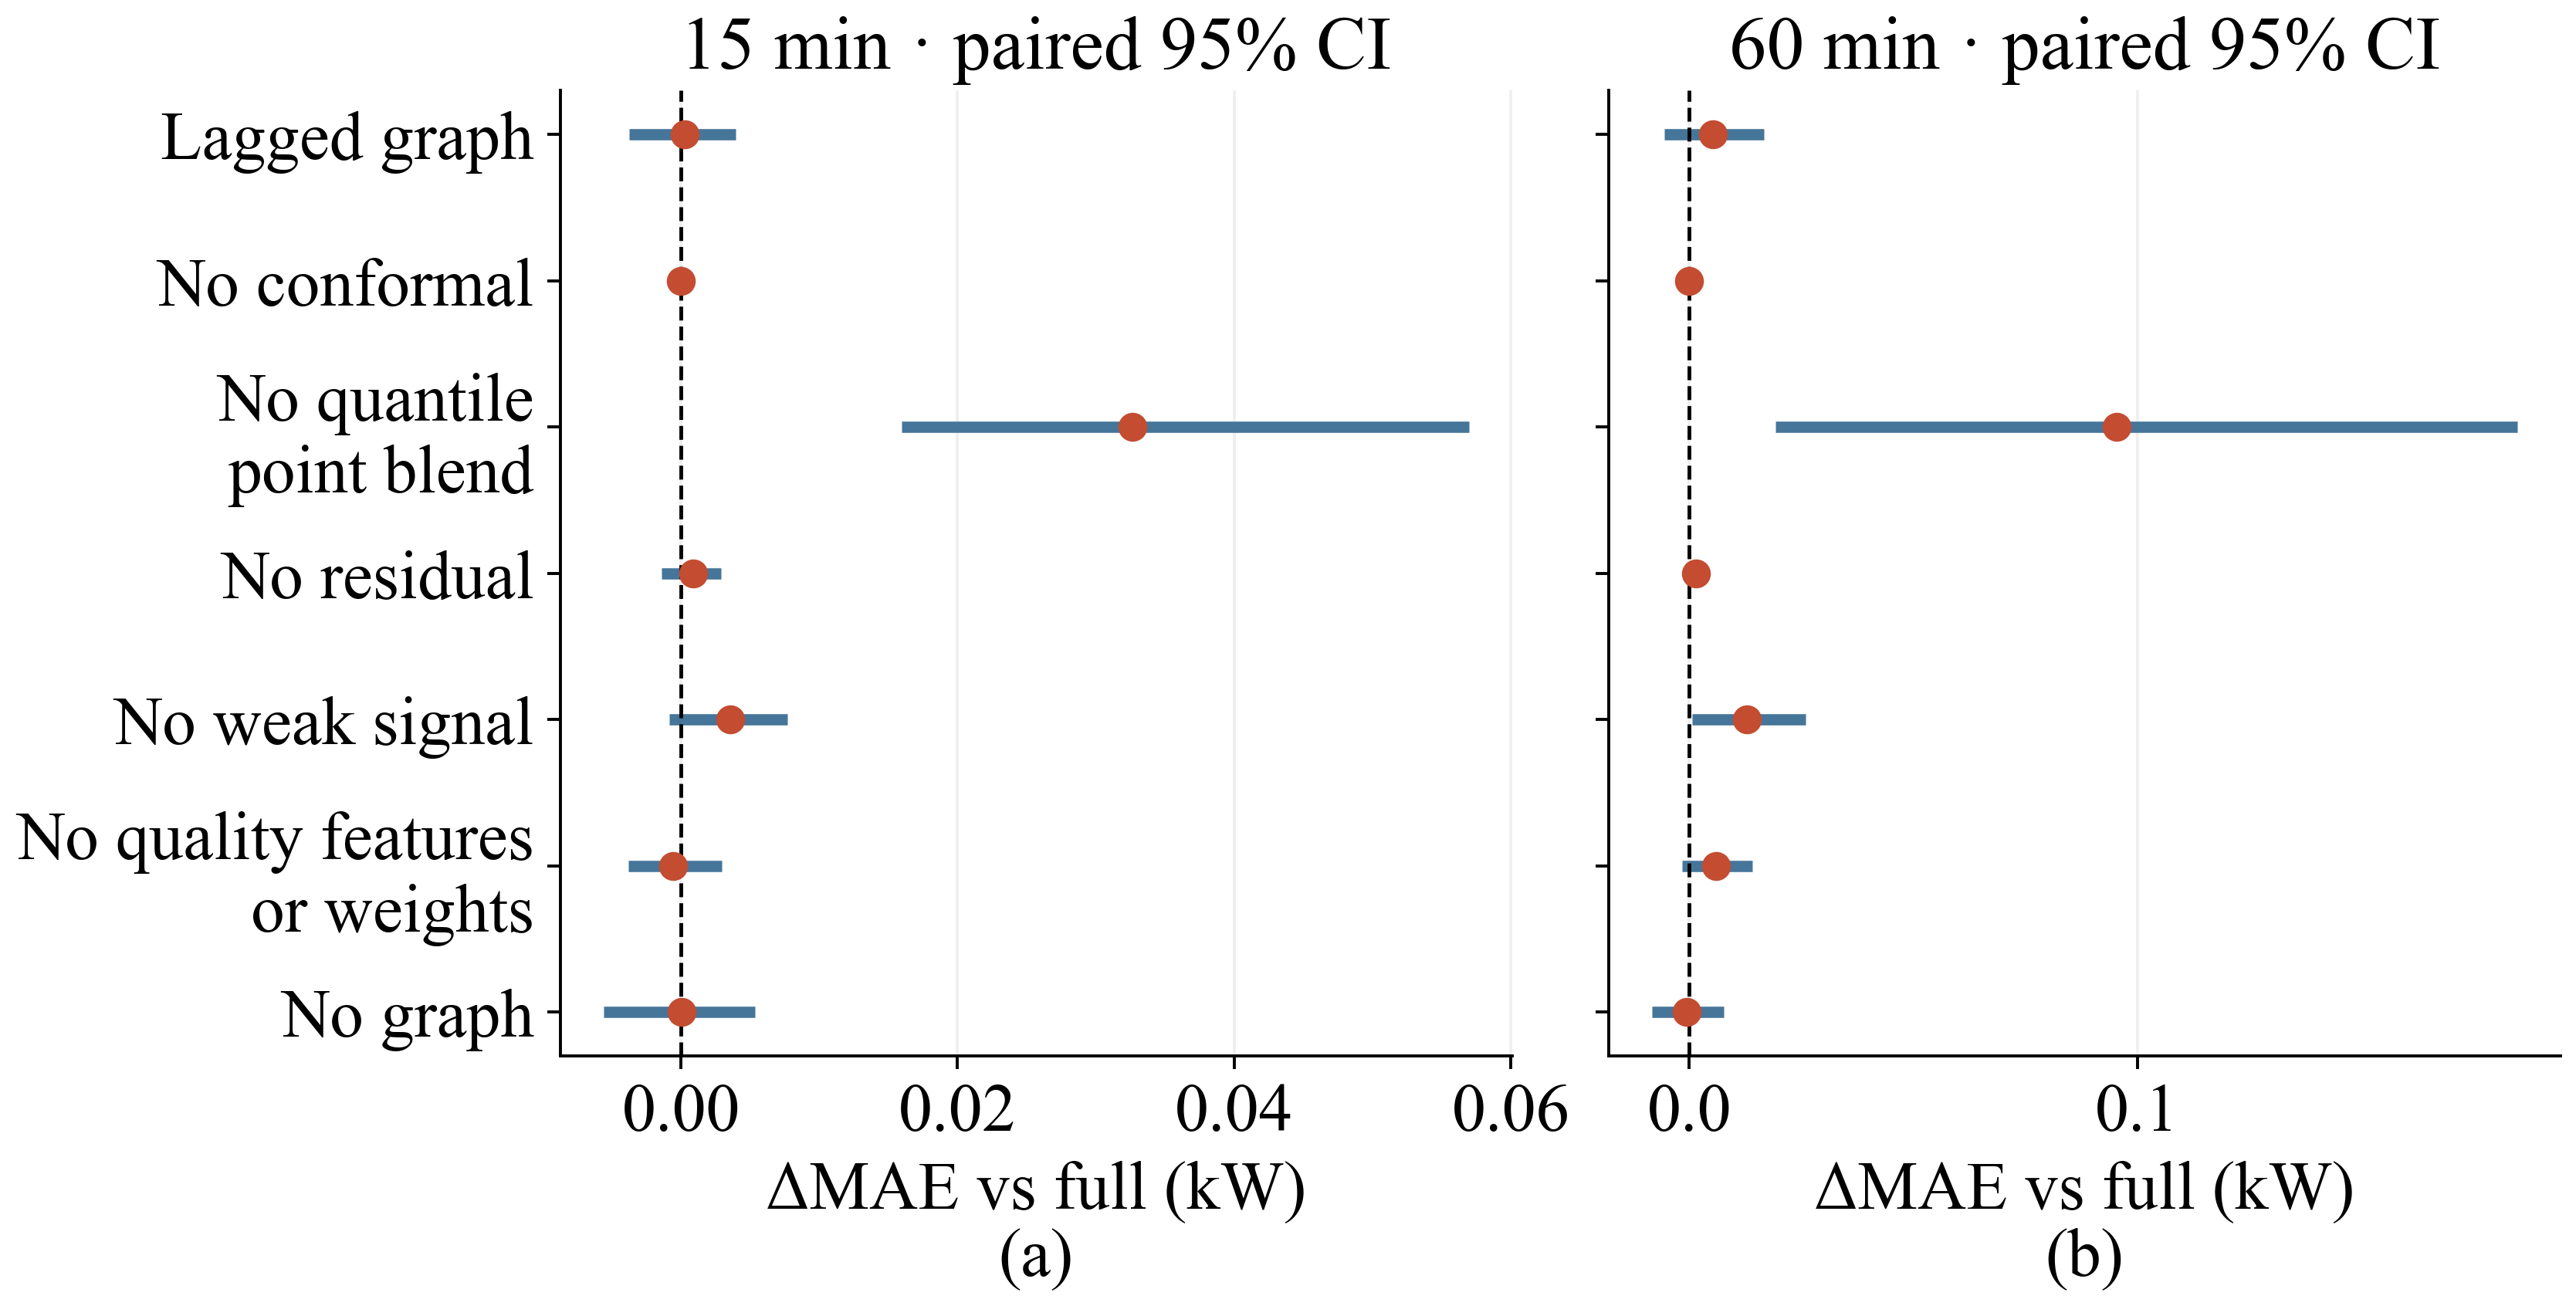

In [6]:
paired=pd.read_csv(TABLE_DIR/'paired_statistical_summary.csv')
fig,axes=plt.subplots(1,2,figsize=(9.5, 4.8),layout='constrained',sharey=True)
for ax,h in zip(axes,[15,60]):
    data=paired.query('experiment=="ablation" and horizon_minutes==@h').copy()
    labels=data.comparator.str.replace('IA-GTPF ','',regex=False).str.replace('without probabilistic branch in point aggregation','without quantile\npoint aggregation',regex=False)
    labels=labels.replace({'lagged graph context':'Lagged graph','without conformal calibration':'No conformal','without residual':'No residual','without weak signal':'No weak signal','without quality features and weights':'No quality features\nor weights','without graph':'No graph','without quantile\npoint aggregation':'No quantile\npoint blend'})
    x=data.mean_delta_MAE.to_numpy();lo=data.CI_95_low.to_numpy();hi=data.CI_95_high.to_numpy()
    # Percentile intervals need not contain the original estimate; draw CI segments directly.
    ax.hlines(np.arange(len(data)),lo,hi,color='#46759a',linewidth=3);ax.scatter(x,np.arange(len(data)),color='#c34c31',s=45,zorder=3)
    ax.axvline(0,color='black',linestyle='--',linewidth=1)
    ax.set(yticks=np.arange(len(data)),yticklabels=labels,xlabel='ΔMAE vs full (kW)',title=f'{h} min · paired 95% CI');ax.grid(axis='x',alpha=.2)
panel_letters(axes);save_figure(fig,'revision_ablation_uncertainty',paired.query('experiment=="ablation"'))


Points and intervals are the paired ablation estimates across five temporal origins and five seeds. Pure conformal removal leaves point predictions unchanged. Component effects whose intervals cross zero are not established improvements.

## IA-GTPF architecture

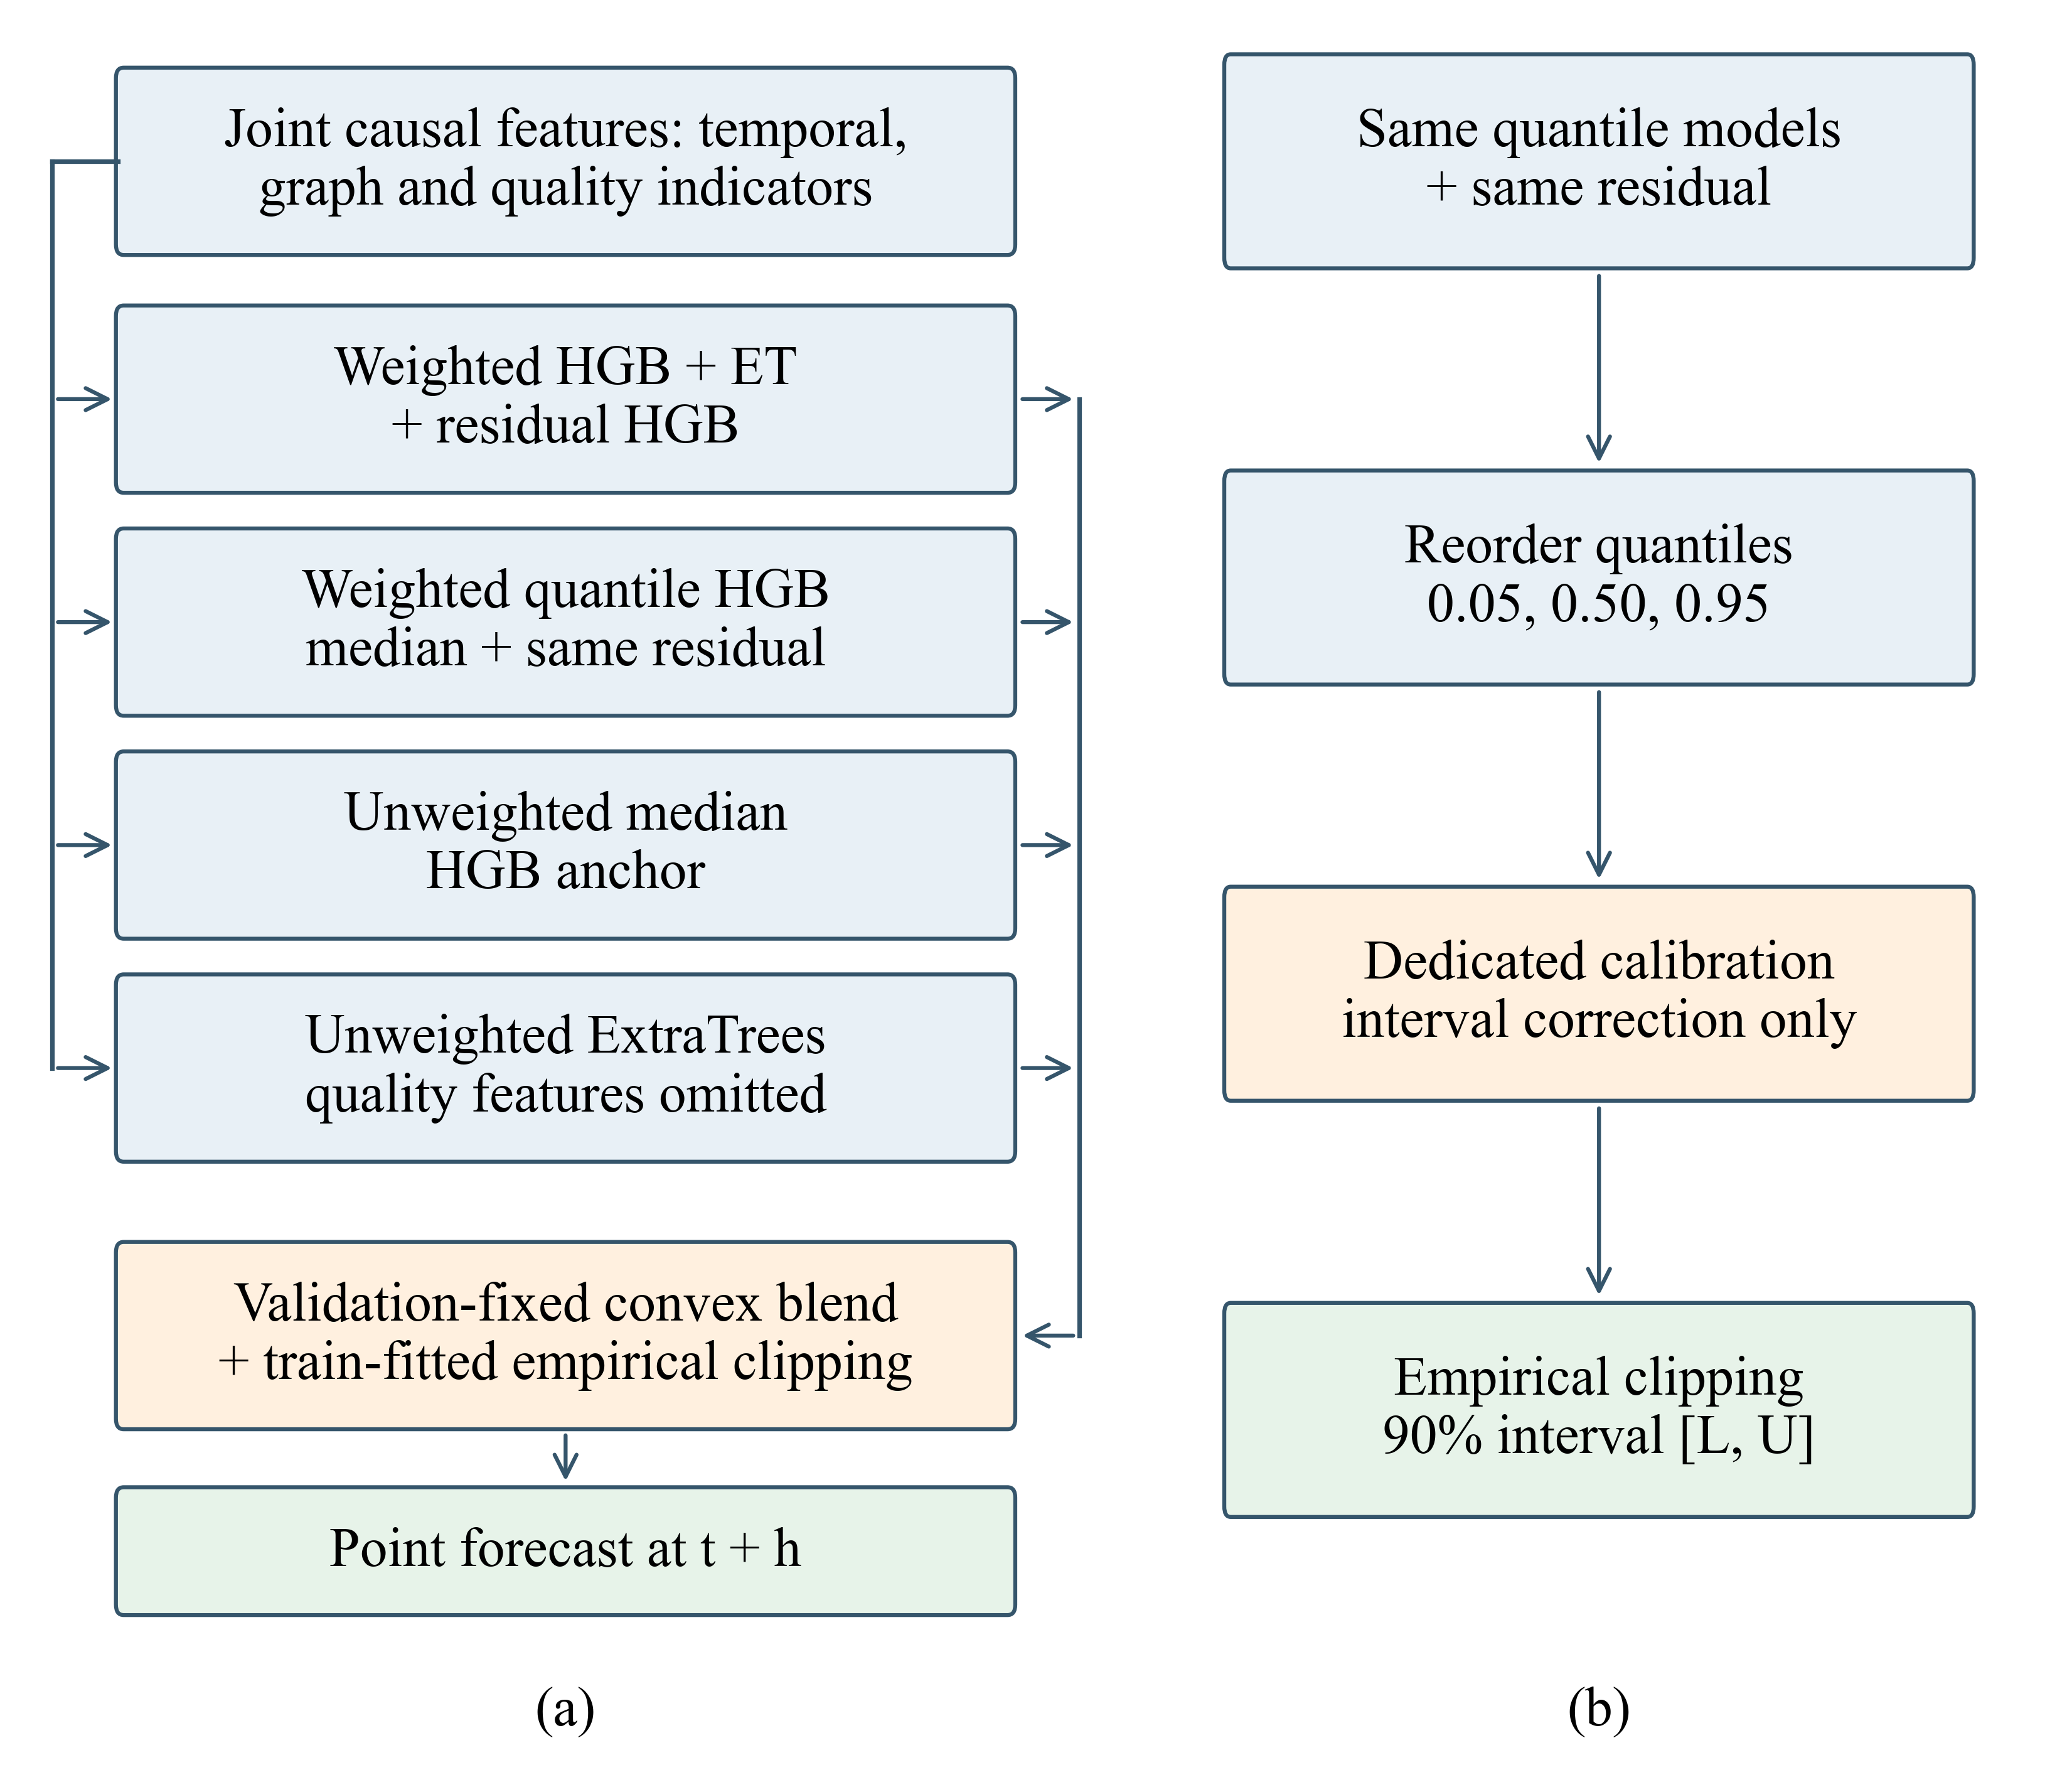

In [7]:
from matplotlib.patches import FancyBboxPatch
fig, axes = plt.subplots(1, 2, figsize=(9.4, 8.0), layout='constrained', gridspec_kw={'width_ratios':[1.2,1]})
for ax in axes:
    ax.set(xlim=(0,10),ylim=(-.7,11));ax.axis('off')
def box(ax, y, text, color='#e8f0f6', height=1.12):
    ax.add_patch(FancyBboxPatch((1.0,y-height/2),8.0,height,boxstyle='round,pad=.07',facecolor=color,edgecolor='#35556b',linewidth=1.3))
    ax.text(5,y,text,ha='center',va='center',fontsize=18)
def arrow(ax,a,b):
    ax.annotate('',xy=b,xytext=a,arrowprops={'arrowstyle':'->','linewidth':1.3,'color':'#35556b'})
box(axes[0],10,'Joint causal features: temporal,\ngraph and quality indicators')
branches=['Weighted HGB + ET\n+ residual HGB','Weighted quantile HGB\nmedian + same residual','Unweighted median\nHGB anchor','Unweighted ExtraTrees\nquality features omitted']
for y,label in zip([8.4,6.9,5.4,3.9],branches):
    box(axes[0],y,label)
    arrow(axes[0],(.35,y),(.95,y));arrow(axes[0],(9.08,y),(9.65,y))
axes[0].plot([.35,.35],[3.9,10],color='#35556b');axes[0].plot([.35,.95],[10,10],color='#35556b')
axes[0].plot([9.65,9.65],[2.1,8.4],color='#35556b');arrow(axes[0],(9.65,2.1),(9.08,2.1))
box(axes[0],2.1,'Validation-fixed convex blend\n+ train-fitted empirical clipping','#fff0df')
arrow(axes[0],(5,1.47),(5,1.08));box(axes[0],.65,'Point forecast at t + h','#e7f3e9',.72)
for y,label,color in [(10,'Same quantile models\n+ same residual','#e8f0f6'),(7.2,'Reorder quantiles\n0.05, 0.50, 0.95','#e8f0f6'),(4.4,'Dedicated calibration\ninterval correction only','#fff0df'),(1.6,'Empirical clipping\n90% interval [L, U]','#e7f3e9')]:
    box(axes[1],y,label,color,height=1.3)
for upper,lower in [(10,7.2),(7.2,4.4),(4.4,1.6)]:arrow(axes[1],(5,upper-.73),(5,lower+.73))
for ax,letter in zip(axes,['a','b']):ax.text(5,-.43,f'({letter})',ha='center',va='center',fontsize=18)
save_figure(fig,'revision_actual_ia_gtpf_architecture',pd.read_csv(VISUAL_DATA/'revision_actual_ia_gtpf_architecture.csv',index_col=0))


The ensemble produces point forecasts and prediction intervals through separate paths. Calibration adjusts interval endpoints while preserving point forecasts.

## Residual-branch contribution across temporal origins

Source: frozen repeated-ablation metrics; no residual refitting.

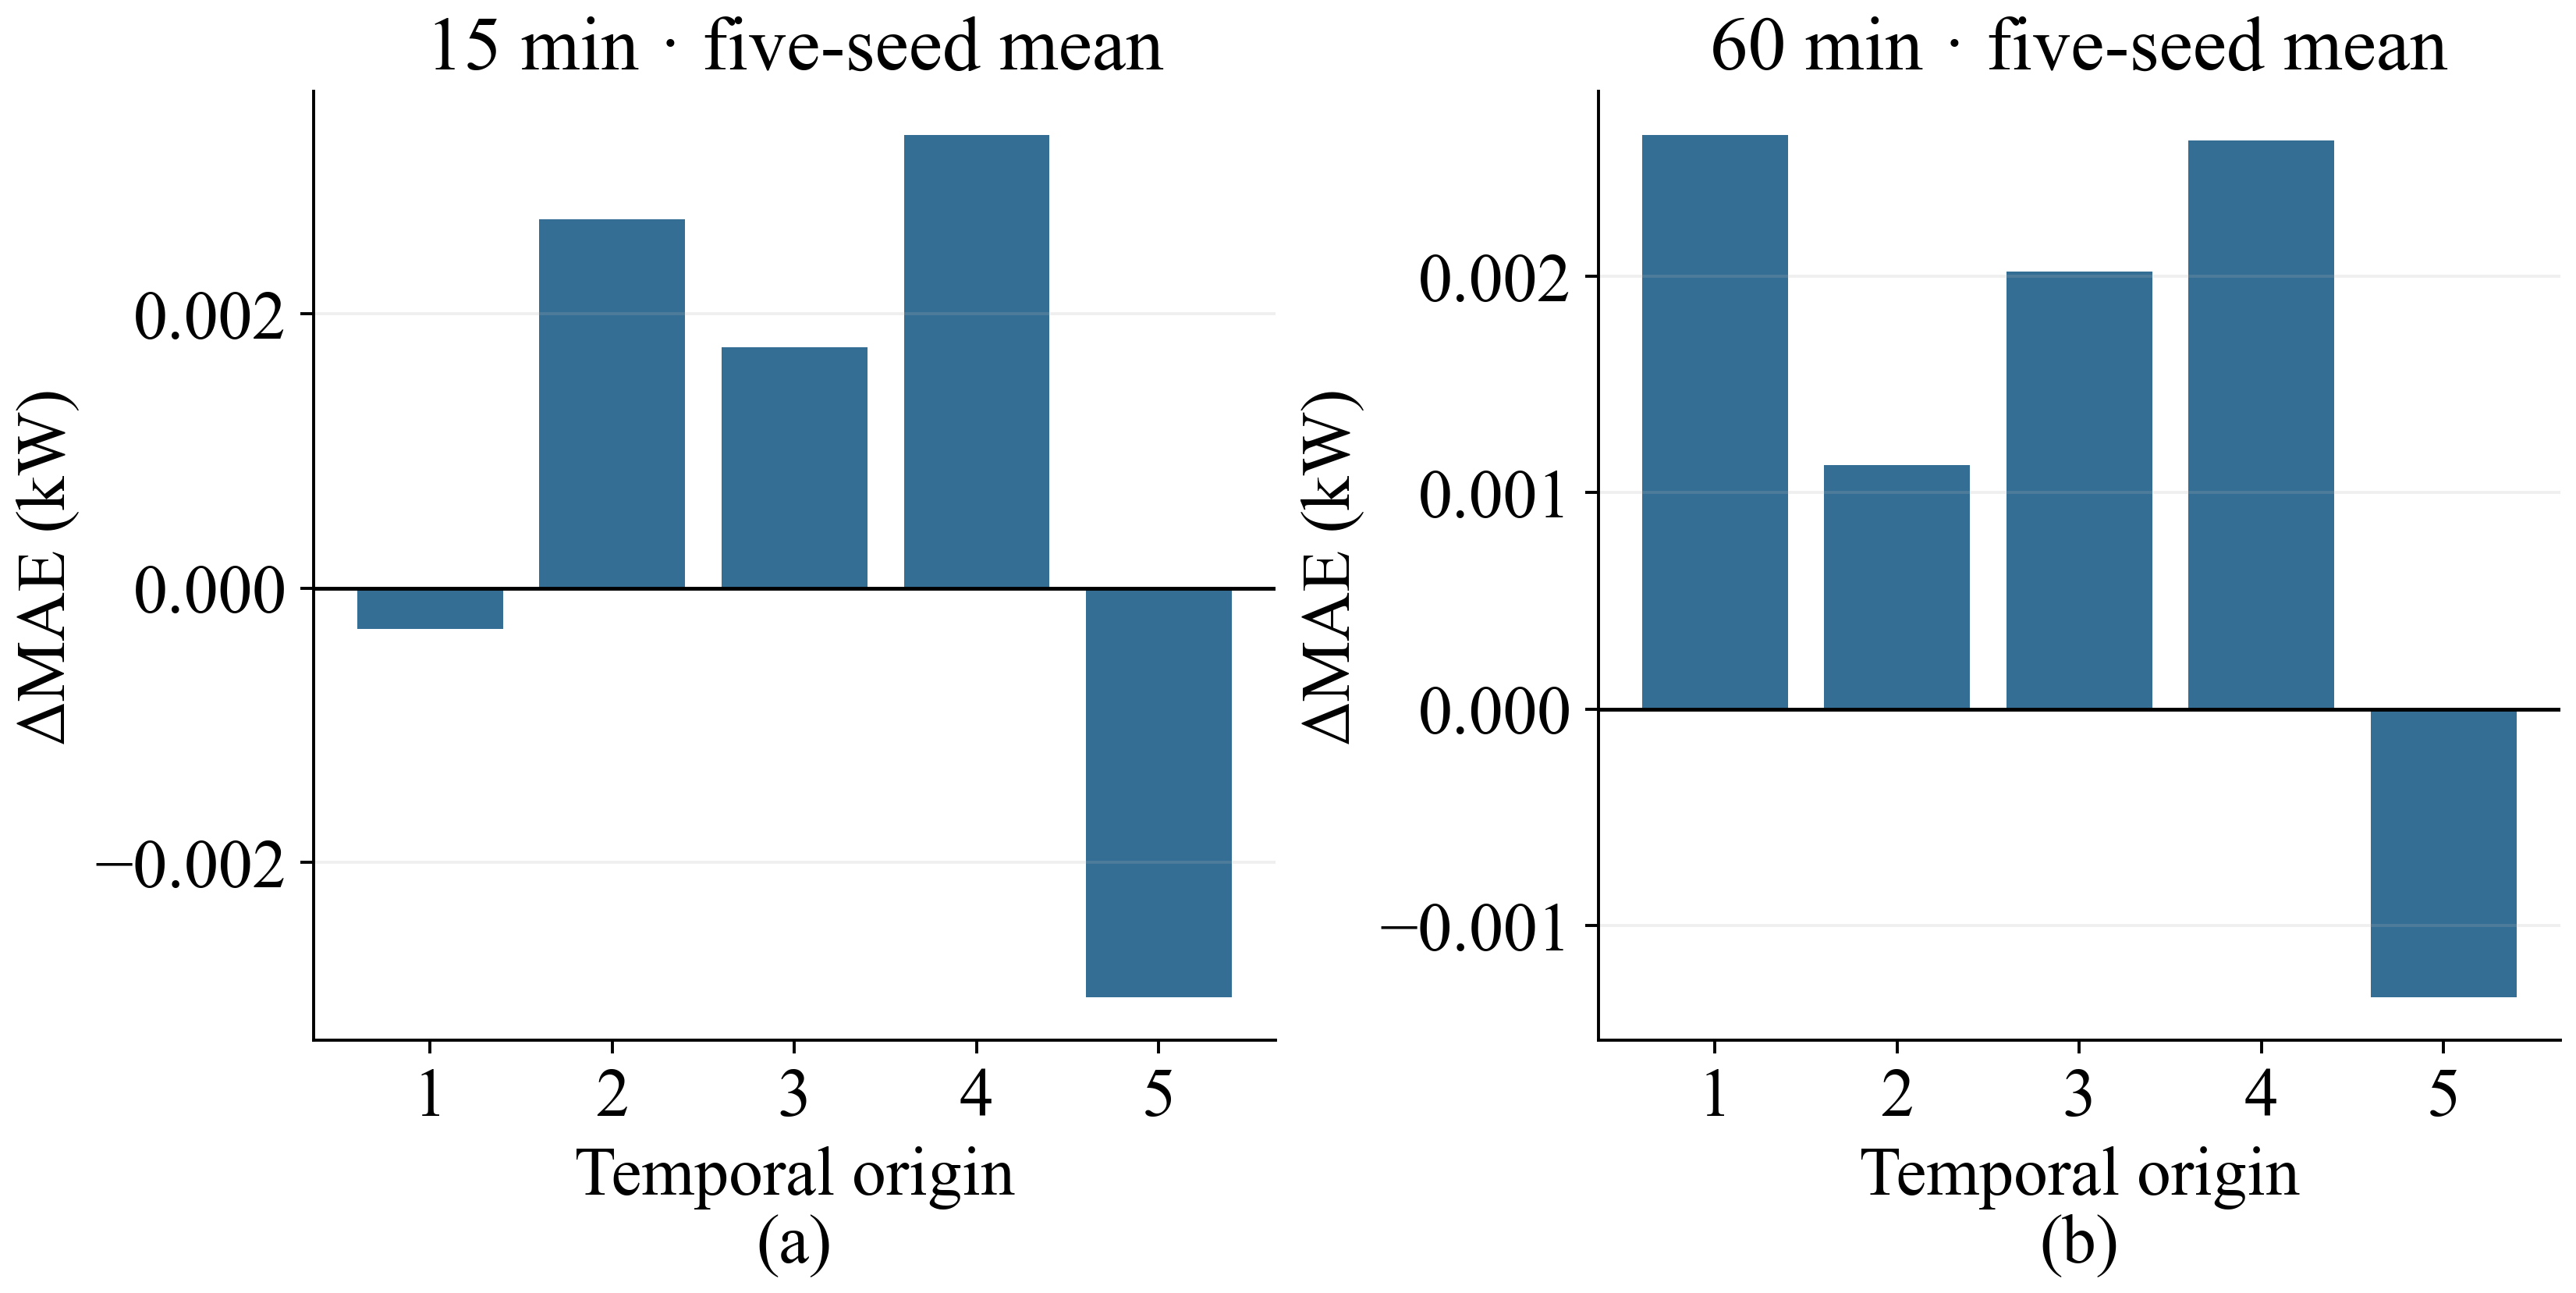

In [8]:
g=pd.read_csv(VISUAL_DATA/'revision_residual_branch_effect.csv',index_col=[0,1])
fig,axes=plt.subplots(1,2,figsize=(9.4, 4.7),layout='constrained')
for ax,h in zip(axes,[15,60]):
    z=g.xs(h,level='horizon_minutes');ax.bar(z.index,z.without_minus_full,color=C['blue']);ax.axhline(0,color='black',lw=1);ax.set(xlabel='Temporal origin',ylabel='ΔMAE (kW)',title=f'{h} min · five-seed mean',xticks=range(1,6));ax.grid(axis='y',alpha=.2)
panel_letters(axes);save_figure(fig,'revision_residual_branch_effect',g)


The residual contribution varies across horizons and temporal origins. Positive values indicate lower error for the full model.

ΔMAE = MAE without the residual branch − MAE of the full model.